# High-Resolution Irregular Correlation Geometry Diagnostic

This notebook repeats the low-resolution correlation-geometry diagnostic using a real GEMS observation pattern.

It builds:

- base Vecchia grid at `0.044 x 0.063`
- high-resolution simulation grid at `lat x100`, `lon x10`
- one randomly selected 2024 July day of real source locations
- irregular per-time maps by assigning real source locations to base Vecchia cells and high-resolution simulation cells

Then it asks, for each valid target at time `t`, whether the lagged candidate set is highly correlated with the target under the true advection covariance.

Candidate sets compared at lag 1 and lag 2:

- `local_reuse_nn_only`: reuse current-location max-min NN indices at lagged time
- `local_anchor_plus_nn`: same-location lag anchor plus current-location NN indices
- `parallel_shift_t_nn`: shift the current-time NN cloud eastward and snap to available lagged observations
- `fresh_shift_center_nn`: move the lagged center first, then take fresh NN around that center
- `hybrid_anchor_plus_fresh`: same-location anchor plus fresh shifted-center candidates

This is a geometry/correlation diagnostic only. It does not fit Vecchia models.

In [1]:
import os
import sys
import pickle
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.neighbors import BallTree

AMAREL_SRC = "/home/jl2815/tco"
LOCAL_SRC = "/Users/joonwonlee/Documents/GEMS_TCO-1/src"
_src = AMAREL_SRC if os.path.exists(AMAREL_SRC) else LOCAL_SRC
sys.path.insert(0, _src)

from GEMS_TCO import configuration as config
from GEMS_TCO import orderings as _orderings

is_amarel = os.path.exists(config.amarel_data_load_path)
DATA_PATH = config.amarel_data_load_path if is_amarel else config.mac_data_load_path

print("SRC:", _src)
print("DATA_PATH:", DATA_PATH)


SRC: /Users/joonwonlee/Documents/GEMS_TCO-1/src
DATA_PATH: /Users/joonwonlee/Documents/GEMS_DATA/


## Settings


In [2]:
YEAR = "2024"
MONTH = 7
LAT_RANGE = (-3.0, 2.0)
LON_RANGE = (121.0, 131.0)

DELTA_LAT_BASE = 0.044
DELTA_LON_BASE = 0.063
LAT_FACTOR = 100
LON_FACTOR = 10
T_STEPS = 8

MM_COND_NUMBER = 100
TOP_K = 8
MIN_ORDER_POS = 40
TARGET_T_IDX = 4  # must be >= 2 to compare lag 1 and lag 2
MAX_TARGETS = 2000  # None = all valid targets; 1000-3000 is usually enough for diagnostics
SEED = 42

TRUE_DICT_BASE = {
    "sigmasq": 10.0,
    "range_lat": 0.30,
    "range_lon": 0.40,
    "range_time": 2.0,
    "advec_lat": 0.08,
    "nugget": 2.5,
}
TRUE_ADVEC_LON_LIST = [-0.10, -0.126, -0.16, -0.25]
PRED_LAG1_LON_OFFSETS = [0.10, 0.126, 0.16, 0.20, 0.25]
LAGS = [1, 2]

RANDOM_DAY_INDEX = None  # None = random day from the month; set an integer for reproducibility.
SAVE_CSV = True
OUT_PREFIX = "sim_vecchia_irregular2024_highres_corr_geometry_050126"

print(f"base grid step: lat={DELTA_LAT_BASE}, lon={DELTA_LON_BASE}")
print(f"high-res step: lat={DELTA_LAT_BASE/LAT_FACTOR}, lon={DELTA_LON_BASE/LON_FACTOR}")
print("predicted lag1 offsets in base lon cells:", [round(v / DELTA_LON_BASE, 3) for v in PRED_LAG1_LON_OFFSETS])


base grid step: lat=0.044, lon=0.063
high-res step: lat=0.00043999999999999996, lon=0.0063
predicted lag1 offsets in base lon cells: [1.587, 2.0, 2.54, 3.175, 3.968]


## Load One Real 2024 Day Pattern


In [3]:
def load_tco_grid_map(data_path, year=YEAR, month=MONTH):
    yy = str(year)[2:]
    path = Path(data_path) / f"pickle_{year}" / f"tco_grid_{yy}_{month:02d}.pkl"
    if not path.exists():
        raise FileNotFoundError(path)
    with open(path, "rb") as f:
        raw = pickle.load(f)
    return raw, path

def filter_source_bbox(df, lat_range=LAT_RANGE, lon_range=LON_RANGE):
    lat_col = "Source_Latitude" if "Source_Latitude" in df.columns else "Latitude"
    lon_col = "Source_Longitude" if "Source_Longitude" in df.columns else "Longitude"
    out = df.copy()
    out[lat_col] = pd.to_numeric(out[lat_col], errors="coerce")
    out[lon_col] = pd.to_numeric(out[lon_col], errors="coerce")
    mask = (
        out[lat_col].between(min(lat_range), max(lat_range))
        & out[lon_col].between(min(lon_range), max(lon_range))
    )
    return out.loc[mask].reset_index(drop=True)

raw_tco_map, raw_path = load_tco_grid_map(DATA_PATH, YEAR, MONTH)
all_keys = sorted(raw_tco_map.keys())
n_days = len(all_keys) // T_STEPS
rng = np.random.default_rng(SEED)
if RANDOM_DAY_INDEX is None:
    DAY_INDEX = int(rng.integers(0, n_days))
else:
    DAY_INDEX = int(RANDOM_DAY_INDEX)
DAY_INDEX = max(0, min(DAY_INDEX, n_days - 1))
day_keys = all_keys[DAY_INDEX * T_STEPS : (DAY_INDEX + 1) * T_STEPS]
ref_day_map = {k: filter_source_bbox(raw_tco_map[k]) for k in day_keys}

print("loaded:", raw_path)
print("available slots:", len(all_keys), "days:", n_days)
print("selected DAY_INDEX:", DAY_INDEX)
print("day keys:", day_keys)
print("rows per selected slot:", {k: len(v) for k, v in ref_day_map.items()})
print("columns:", list(next(iter(ref_day_map.values())).columns)[:20])


loaded: /Users/joonwonlee/Documents/GEMS_DATA/pickle_2024/tco_grid_24_07.pkl
available slots: 248 days: 31
selected DAY_INDEX: 2
day keys: ['y24m07day03_hm00:53', 'y24m07day03_hm01:53', 'y24m07day03_hm02:53', 'y24m07day03_hm03:53', 'y24m07day03_hm04:48', 'y24m07day03_hm05:48', 'y24m07day03_hm06:48', 'y24m07day03_hm07:48']
rows per selected slot: {'y24m07day03_hm00:53': 18067, 'y24m07day03_hm01:53': 17670, 'y24m07day03_hm02:53': 16698, 'y24m07day03_hm03:53': 16863, 'y24m07day03_hm04:48': 17088, 'y24m07day03_hm05:48': 17760, 'y24m07day03_hm06:48': 18104, 'y24m07day03_hm07:48': 18102}
columns: ['Latitude', 'Longitude', 'ColumnAmountO3', 'Hours_elapsed', 'Source_Latitude', 'Source_Longitude']


## Build Base And High-Resolution Grids


In [4]:
def build_base_grid(lat_range=LAT_RANGE, lon_range=LON_RANGE):
    lats = np.round(np.arange(min(lat_range), max(lat_range) + 0.0001, DELTA_LAT_BASE), 4)
    lons = np.round(np.arange(lon_range[0], lon_range[1] + 0.0001, DELTA_LON_BASE), 4)
    g_lat, g_lon = np.meshgrid(lats, lons, indexing="ij")
    coords = np.column_stack([g_lat.ravel(), g_lon.ravel()]).astype(np.float64)
    return lats, lons, coords

def build_high_res_grid(lat_range=LAT_RANGE, lon_range=LON_RANGE, lat_factor=LAT_FACTOR, lon_factor=LON_FACTOR):
    dlat = DELTA_LAT_BASE / lat_factor
    dlon = DELTA_LON_BASE / lon_factor
    lats = np.arange(min(lat_range) - 0.1, max(lat_range) + 0.1, dlat, dtype=np.float64)
    lons = np.arange(lon_range[0] - 0.1, lon_range[1] + 0.1, dlon, dtype=np.float64)
    g_lat, g_lon = np.meshgrid(lats, lons, indexing="ij")
    coords = np.column_stack([g_lat.ravel(), g_lon.ravel()]).astype(np.float64)
    return lats, lons, coords, dlat, dlon

lats_base, lons_base, base_coords = build_base_grid()
lats_hr, lons_hr, hr_coords, dlat_hr, dlon_hr = build_high_res_grid()
print(f"base grid: {len(lats_base)} x {len(lons_base)} = {len(base_coords):,}")
print(f"high-res grid: {len(lats_hr)} x {len(lons_hr)} = {len(hr_coords):,}")


base grid: 114 x 159 = 18,126
high-res grid: 11819 x 1620 = 19,146,780


## Map Real Source Locations To Base Cells And High-Resolution Cells


In [5]:
def apply_step3_1to1(src_np_valid, grid_coords_np, grid_tree):
    n_grid = len(grid_coords_np)
    if len(src_np_valid) == 0:
        return np.full(n_grid, -1, dtype=np.int64)

    dist_to_cell, cell_for_obs = grid_tree.query(np.radians(src_np_valid), k=1)
    dist_to_cell = dist_to_cell.flatten()
    cell_for_obs = cell_for_obs.flatten()

    assignment = np.full(n_grid, -1, dtype=np.int64)
    best_dist = np.full(n_grid, np.inf)
    for obs_i, (cell_j, dist) in enumerate(zip(cell_for_obs, dist_to_cell)):
        if dist < best_dist[cell_j]:
            assignment[cell_j] = obs_i
            best_dist[cell_j] = dist

    filled = assignment >= 0
    if filled.any():
        win_obs = assignment[filled]
        lat_diff = np.abs(src_np_valid[win_obs, 0] - grid_coords_np[filled, 0])
        lon_diff = np.abs(src_np_valid[win_obs, 1] - grid_coords_np[filled, 1])
        too_far = (lat_diff > DELTA_LAT_BASE / 2) | (lon_diff > DELTA_LON_BASE / 2)
        assignment[np.where(filled)[0][too_far]] = -1
    return assignment

def extract_source_coords(df):
    lat_col = "Source_Latitude" if "Source_Latitude" in df.columns else "Latitude"
    lon_col = "Source_Longitude" if "Source_Longitude" in df.columns else "Longitude"
    src = df[[lat_col, lon_col]].apply(pd.to_numeric, errors="coerce").to_numpy(dtype=np.float64)
    src = src[~np.isnan(src).any(axis=1)]
    return src

def precompute_day_mapping(ref_day_map, base_coords, hr_coords, sorted_keys):
    base_tree = BallTree(np.radians(base_coords), metric="haversine")
    hr_tree = BallTree(np.radians(hr_coords), metric="haversine")
    assignments = []
    source_locs = []
    hr_indices = []
    hr_distances = []
    for key in sorted_keys:
        src = extract_source_coords(ref_day_map.get(key, pd.DataFrame()))
        assignment = apply_step3_1to1(src, base_coords, base_tree)
        assignments.append(assignment)
        source_locs.append(src)
        if len(src):
            dist, idx = hr_tree.query(np.radians(src), k=1)
            hr_indices.append(idx.flatten().astype(np.int64))
            hr_distances.append(dist.flatten())
        else:
            hr_indices.append(np.array([], dtype=np.int64))
            hr_distances.append(np.array([], dtype=np.float64))
    return assignments, source_locs, hr_indices, hr_distances

assignments, source_locs, hr_indices, hr_distances = precompute_day_mapping(ref_day_map, base_coords, hr_coords, day_keys)

map_rows = []
for t_idx, key in enumerate(day_keys):
    assign = assignments[t_idx]
    valid_cells = np.where(assign >= 0)[0]
    src = source_locs[t_idx]
    map_rows.append({
        "t_idx": t_idx,
        "key": key,
        "source_rows_in_bbox": len(src),
        "assigned_base_cells": len(valid_cells),
        "assignment_rate": len(valid_cells) / max(len(base_coords), 1),
        "median_hr_haversine_rad": float(np.median(hr_distances[t_idx])) if len(hr_distances[t_idx]) else np.nan,
    })
map_summary = pd.DataFrame(map_rows)
display(map_summary)


,t_idx,key,source_rows_in_bbox,assigned_base_cells,assignment_rate,median_hr_haversine_rad
0,0,y24m07day03_hm00:53,18067,17251,0.951727,0.000028
1,1,y24m07day03_hm01:53,17670,16837,0.928887,0.000027
2,2,y24m07day03_hm02:53,16698,15845,0.874159,0.000027
3,3,y24m07day03_hm03:53,16863,15984,0.881827,0.000028
4,4,y24m07day03_hm04:48,17088,16216,0.894627,0.000028
5,5,y24m07day03_hm05:48,17760,16903,0.932528,0.000027
6,6,y24m07day03_hm06:48,18104,17273,0.952941,0.000027
7,7,y24m07day03_hm07:48,18102,17285,0.953603,0.000028


## Max-Min Ordering On Base Vecchia Grid


In [6]:
print("Computing max-min ordering and NNS map...")
ord_grid = _orderings.maxmin_cpp(base_coords)
nns_grid = _orderings.find_nns_l2(locs=base_coords[ord_grid], max_nn=MM_COND_NUMBER)
ordered_base_coords = base_coords[ord_grid]
inv_ord = np.empty_like(ord_grid)
inv_ord[ord_grid] = np.arange(len(ord_grid))
print("ordering done; N=", len(ord_grid))


Computing max-min ordering and NNS map...
ordering done; N= 18126


## Ordered Irregular Coordinates By Time


In [7]:
def build_coords_by_time_ordered(assignments, source_locs, ord_grid):
    n = len(ord_grid)
    coords_by_t = []
    valid_by_t = []
    for assign, src in zip(assignments, source_locs):
        coords = np.full((n, 2), np.nan, dtype=np.float64)
        filled_base = np.where(assign >= 0)[0]
        if len(filled_base):
            coords[filled_base] = src[assign[filled_base]]
        coords_ord = coords[ord_grid]
        valid = ~np.isnan(coords_ord).any(axis=1)
        coords_by_t.append(coords_ord)
        valid_by_t.append(valid)
    return coords_by_t, valid_by_t

coords_by_t, valid_by_t = build_coords_by_time_ordered(assignments, source_locs, ord_grid)
for t_idx, key in enumerate(day_keys):
    print(t_idx, key, "valid ordered rows:", int(valid_by_t[t_idx].sum()))


0 y24m07day03_hm00:53 valid ordered rows: 17251
1 y24m07day03_hm01:53 valid ordered rows: 16837
2 y24m07day03_hm02:53 valid ordered rows: 15845
3 y24m07day03_hm03:53 valid ordered rows: 15984
4 y24m07day03_hm04:48 valid ordered rows: 16216
5 y24m07day03_hm05:48 valid ordered rows: 16903
6 y24m07day03_hm06:48 valid ordered rows: 17273
7 y24m07day03_hm07:48 valid ordered rows: 17285


## Correlation And Candidate Set Helpers


In [8]:
def make_true_dict(advec_lon):
    return {**TRUE_DICT_BASE, "advec_lon": float(advec_lon)}

def true_to_log_params(true_dict):
    phi2 = 1.0 / true_dict["range_lon"]
    phi1 = true_dict["sigmasq"] * phi2
    phi3 = (true_dict["range_lon"] / true_dict["range_lat"]) ** 2
    phi4 = (true_dict["range_lon"] / true_dict["range_time"]) ** 2
    return np.array([
        np.log(phi1), np.log(phi2), np.log(phi3), np.log(phi4),
        true_dict["advec_lat"], true_dict["advec_lon"], np.log(true_dict["nugget"]),
    ], dtype=np.float64)

def latent_corr_current_to_candidate(target_coord, cand_coords, dt, true_dict):
    p = true_to_log_params(true_dict)
    phi2 = np.exp(p[1])
    phi3 = np.exp(p[2])
    phi4 = np.exp(p[3])
    dlat = target_coord[0] - cand_coords[:, 0]
    dlon = target_coord[1] - cand_coords[:, 1]
    u_lat = dlat - p[4] * dt
    u_lon = dlon - p[5] * dt
    dist = np.sqrt((u_lat ** 2) * phi3 + (u_lon ** 2) + (dt ** 2) * phi4 + 1e-12)
    return np.exp(-dist * phi2)

def nearest_ordered_base_indices(query_coords):
    query_coords = np.asarray(query_coords, dtype=np.float64)
    if query_coords.ndim == 1:
        query_coords = query_coords[None, :]
    tree = BallTree(np.radians(ordered_base_coords), metric="haversine")
    _, idx = tree.query(np.radians(query_coords), k=1)
    return idx.flatten().astype(np.int64)

def nearest_valid_obs_indices(query_coords, valid_coords, valid_indices):
    query_coords = np.asarray(query_coords, dtype=np.float64)
    if query_coords.ndim == 1:
        query_coords = query_coords[None, :]
    if len(valid_indices) == 0:
        return np.array([], dtype=np.int64)
    tree = BallTree(np.radians(valid_coords), metric="haversine")
    _, idx = tree.query(np.radians(query_coords), k=1)
    return valid_indices[idx.flatten()].astype(np.int64)

def build_shift_lookup_base(pred_lag1_offset, multiplier=1.0):
    q = ordered_base_coords.copy()
    q[:, 1] += multiplier * abs(pred_lag1_offset)
    outside = (q[:, 1] < ordered_base_coords[:, 1].min()) | (q[:, 1] > ordered_base_coords[:, 1].max())
    lookup = nearest_ordered_base_indices(q)
    lookup[outside] = np.arange(len(ordered_base_coords), dtype=np.int64)[outside]
    return lookup

def clean_unique(seq, valid_mask=None, exclude=(), k=TOP_K):
    exclude = set(int(x) for x in exclude)
    out = []
    seen = set()
    for x in seq:
        x = int(x)
        if x in exclude or x in seen:
            continue
        if valid_mask is not None and (x >= len(valid_mask) or not valid_mask[x]):
            continue
        seen.add(x)
        out.append(x)
        if len(out) >= k:
            break
    return np.array(out, dtype=np.int64)

def topk_corr_indices(corr, k=TOP_K):
    finite = np.isfinite(corr)
    if finite.sum() == 0:
        return np.array([], dtype=np.int64)
    k = min(k, int(finite.sum()))
    corr2 = corr.copy()
    corr2[~finite] = -np.inf
    idx = np.argpartition(-corr2, k - 1)[:k]
    idx = idx[np.argsort(-corr2[idx])]
    return idx.astype(np.int64)

def ranks_from_corr(corr):
    corr2 = corr.copy()
    corr2[~np.isfinite(corr2)] = -np.inf
    order = np.argsort(-corr2)
    ranks = np.empty_like(order)
    ranks[order] = np.arange(1, len(corr2) + 1)
    return ranks

def set_stats(set_idx, corr, top_idx):
    set_idx = np.asarray(set_idx, dtype=np.int64)
    if len(set_idx) == 0:
        return {"mean_corr": np.nan, "median_corr": np.nan, "min_corr": np.nan, "overlap_topk": 0.0, "mean_rank_pct": np.nan}
    ranks = ranks_from_corr(corr)
    return {
        "mean_corr": float(np.nanmean(corr[set_idx])),
        "median_corr": float(np.nanmedian(corr[set_idx])),
        "min_corr": float(np.nanmin(corr[set_idx])),
        "overlap_topk": float(len(set(set_idx).intersection(set(top_idx))) / max(len(top_idx), 1)),
        "mean_rank_pct": float(np.mean(ranks[set_idx]) / len(corr)),
    }


## Same-Time Diagnostic On The Selected Irregular Pattern


In [9]:
target_valid = valid_by_t[TARGET_T_IDX].copy()
eligible = np.where(target_valid)[0]
eligible = eligible[eligible >= max(MIN_ORDER_POS, TOP_K + 1)]
if MAX_TARGETS is not None and len(eligible) > MAX_TARGETS:
    rng = np.random.default_rng(SEED)
    eligible = np.sort(rng.choice(eligible, size=MAX_TARGETS, replace=False))
print("TARGET_T_IDX:", TARGET_T_IDX, "eligible targets:", len(eligible))

same_rows = []
t_coords = coords_by_t[TARGET_T_IDX]
t_valid = valid_by_t[TARGET_T_IDX]
true_dict = make_true_dict(TRUE_ADVEC_LON_LIST[0])
for i in eligible:
    target = t_coords[i]
    admissible = np.arange(i, dtype=np.int64)
    admissible = admissible[t_valid[admissible]]
    if len(admissible) < TOP_K:
        continue
    corr = np.full(len(ordered_base_coords), -np.inf, dtype=np.float64)
    corr[admissible] = latent_corr_current_to_candidate(target, t_coords[admissible], dt=0.0, true_dict=true_dict)
    top_idx = topk_corr_indices(corr, TOP_K)
    nn_idx = clean_unique(nns_grid[i], valid_mask=t_valid, k=TOP_K)
    st = set_stats(nn_idx, corr, top_idx)
    same_rows.append({
        "target_order_idx": int(i),
        "nn_overlap_corr_topk": st["overlap_topk"],
        "nn_mean_corr": st["mean_corr"],
        "nn_mean_rank_pct": st["mean_rank_pct"],
        "corr_topk_mean_corr": float(np.nanmean(corr[top_idx])),
    })
same_df = pd.DataFrame(same_rows)
display(same_df.describe(percentiles=[0.1, 0.5, 0.9]).T)


TARGET_T_IDX: 4 eligible targets: 2000


,count,mean,std,min,10%,50%,90%,max
target_order_idx,2000.0,9095.686500,5216.999790,61.000000,1906.600000,9022.500000,16421.000000,18120.000000
nn_overlap_corr_topk,2000.0,0.886000,0.090788,0.625000,0.750000,0.875000,1.000000,1.000000
nn_mean_corr,2000.0,0.722682,0.133308,0.015422,0.563296,0.772294,0.822921,0.835190
nn_mean_rank_pct,2000.0,0.000270,0.000025,0.000248,0.000248,0.000262,0.000303,0.000414
corr_topk_mean_corr,2000.0,0.727011,0.132989,0.015586,0.567884,0.776349,0.826638,0.839033


## Lagged Correlation Geometry: Local vs Parallel vs Fresh Shift-Center


In [10]:
lag_rows = []
pair_rows = []

for lag in LAGS:
    lag_t_idx = TARGET_T_IDX - lag
    if lag_t_idx < 0:
        continue
    cand_coords = coords_by_t[lag_t_idx]
    cand_valid = valid_by_t[lag_t_idx]
    valid_indices = np.where(cand_valid)[0]
    valid_coords = cand_coords[valid_indices]

    for true_advec_lon in TRUE_ADVEC_LON_LIST:
        true_dict = make_true_dict(true_advec_lon)
        true_shift = abs(true_advec_lon) * lag
        for pred_offset in PRED_LAG1_LON_OFFSETS:
            pred_shift = abs(pred_offset) * lag
            center_lookup = build_shift_lookup_base(pred_offset, multiplier=lag)

            for i in eligible:
                target = t_coords[i]
                corr = np.full(len(ordered_base_coords), -np.inf, dtype=np.float64)
                corr[valid_indices] = latent_corr_current_to_candidate(target, valid_coords, dt=float(lag), true_dict=true_dict)
                top_idx = topk_corr_indices(corr, TOP_K)
                if len(top_idx) == 0:
                    continue

                t_nn = clean_unique(nns_grid[i], k=TOP_K)
                local_nn = clean_unique(t_nn, valid_mask=cand_valid, k=TOP_K)
                local_anchor = clean_unique([i, *list(nns_grid[i])], valid_mask=cand_valid, k=TOP_K)

                q_parallel = ordered_base_coords[t_nn].copy()
                q_parallel[:, 1] += pred_shift
                parallel = nearest_valid_obs_indices(q_parallel, valid_coords, valid_indices)
                parallel = clean_unique(parallel, valid_mask=cand_valid, k=TOP_K)

                center_idx = int(center_lookup[i])
                fresh = clean_unique([center_idx, *list(nns_grid[center_idx])], valid_mask=cand_valid, k=TOP_K)
                hybrid = clean_unique([i, center_idx, *list(nns_grid[center_idx])], valid_mask=cand_valid, k=TOP_K)

                sets = {
                    "local_reuse_nn_only": local_nn,
                    "local_anchor_plus_nn": local_anchor,
                    "parallel_shift_t_nn": parallel,
                    "fresh_shift_center_nn": fresh,
                    "hybrid_anchor_plus_fresh": hybrid,
                }
                stats = {}
                for set_name, idx in sets.items():
                    st = set_stats(idx, corr, top_idx)
                    stats[set_name] = st
                    lag_rows.append({
                        "lag": int(lag),
                        "target_t_idx": int(TARGET_T_IDX),
                        "candidate_t_idx": int(lag_t_idx),
                        "true_advec_lon": float(true_advec_lon),
                        "true_lag_shift": float(true_shift),
                        "pred_lag1_offset": float(pred_offset),
                        "pred_lag_shift": float(pred_shift),
                        "pred_lag_shift_cells": float(pred_shift / DELTA_LON_BASE),
                        "offset_abs_error": float(abs(pred_shift - true_shift)),
                        "target_order_idx": int(i),
                        "set_name": set_name,
                        "set_size": int(len(idx)),
                        **st,
                    })
                pair_rows.append({
                    "lag": int(lag),
                    "true_advec_lon": float(true_advec_lon),
                    "pred_lag1_offset": float(pred_offset),
                    "target_order_idx": int(i),
                    "fresh_gt_local_anchor": stats["fresh_shift_center_nn"]["mean_corr"] > stats["local_anchor_plus_nn"]["mean_corr"],
                    "fresh_gt_parallel": stats["fresh_shift_center_nn"]["mean_corr"] > stats["parallel_shift_t_nn"]["mean_corr"],
                    "hybrid_gt_local_anchor": stats["hybrid_anchor_plus_fresh"]["mean_corr"] > stats["local_anchor_plus_nn"]["mean_corr"],
                    "hybrid_gt_fresh": stats["hybrid_anchor_plus_fresh"]["mean_corr"] > stats["fresh_shift_center_nn"]["mean_corr"],
                    "fresh_minus_local_anchor": stats["fresh_shift_center_nn"]["mean_corr"] - stats["local_anchor_plus_nn"]["mean_corr"],
                    "fresh_minus_parallel": stats["fresh_shift_center_nn"]["mean_corr"] - stats["parallel_shift_t_nn"]["mean_corr"],
                    "hybrid_minus_local_anchor": stats["hybrid_anchor_plus_fresh"]["mean_corr"] - stats["local_anchor_plus_nn"]["mean_corr"],
                })

lag_df = pd.DataFrame(lag_rows)
pair_df = pd.DataFrame(pair_rows)
print("lag_df:", lag_df.shape, "pair_df:", pair_df.shape)


lag_df: (400000, 17) pair_df: (80000, 11)


## Summary Tables


In [11]:
def p90_p10(x):
    x = np.asarray(x, dtype=float)
    x = x[np.isfinite(x)]
    return float(np.percentile(x, 90) - np.percentile(x, 10)) if len(x) else np.nan

lag_summary = (
    lag_df
    .groupby(["lag", "true_advec_lon", "pred_lag1_offset", "set_name"], sort=True)
    .agg(
        n=("target_order_idx", "count"),
        set_size_mean=("set_size", "mean"),
        mean_corr=("mean_corr", "mean"),
        median_corr=("mean_corr", "median"),
        p90_p10_corr=("mean_corr", p90_p10),
        overlap_topk_mean=("overlap_topk", "mean"),
        mean_rank_pct=("mean_rank_pct", "mean"),
        offset_abs_error=("offset_abs_error", "first"),
        pred_lag_shift_cells=("pred_lag_shift_cells", "first"),
    )
    .reset_index()
)

pair_summary = (
    pair_df
    .groupby(["lag", "true_advec_lon", "pred_lag1_offset"], sort=True)
    .agg(
        n=("target_order_idx", "count"),
        fresh_gt_local_anchor_rate=("fresh_gt_local_anchor", "mean"),
        fresh_gt_parallel_rate=("fresh_gt_parallel", "mean"),
        hybrid_gt_local_anchor_rate=("hybrid_gt_local_anchor", "mean"),
        hybrid_gt_fresh_rate=("hybrid_gt_fresh", "mean"),
        fresh_minus_local_anchor_mean=("fresh_minus_local_anchor", "mean"),
        fresh_minus_parallel_mean=("fresh_minus_parallel", "mean"),
        hybrid_minus_local_anchor_mean=("hybrid_minus_local_anchor", "mean"),
    )
    .reset_index()
)

print("Lag summary sorted within each lag/true/pred by mean_corr:")
display(lag_summary.sort_values(["lag", "true_advec_lon", "pred_lag1_offset", "mean_corr"], ascending=[True, True, True, False]))
print("Pairwise win-rate summary:")
display(pair_summary)

if SAVE_CSV:
    out_dir = Path("log")
    out_dir.mkdir(exist_ok=True)
    lag_path = out_dir / f"{OUT_PREFIX}_lag_summary.csv"
    pair_path = out_dir / f"{OUT_PREFIX}_pair_summary.csv"
    same_path = out_dir / f"{OUT_PREFIX}_same_time_summary.csv"
    lag_summary.to_csv(lag_path, index=False)
    pair_summary.to_csv(pair_path, index=False)
    same_df.to_csv(same_path, index=False)
    print("Saved:", lag_path, pair_path, same_path)


Lag summary sorted within each lag/true/pred by mean_corr:


,lag,true_advec_lon,pred_lag1_offset,set_name,n,set_size_mean,mean_corr,median_corr,p90_p10_corr,overlap_topk_mean,mean_rank_pct,offset_abs_error,pred_lag_shift_cells
0,1,-0.25,0.10,fresh_shift_center_nn,2000,7.9965,0.480937,0.496203,0.104924,0.120313,0.003151,0.15,1.587302
1,1,-0.25,0.10,hybrid_anchor_plus_fresh,2000,7.9965,0.478653,0.491079,0.088082,0.107938,0.002978,0.15,1.587302
4,1,-0.25,0.10,parallel_shift_t_nn,2000,7.7395,0.463663,0.473972,0.099386,0.094125,0.003007,0.15,1.587302
2,1,-0.25,0.10,local_anchor_plus_nn,2000,7.9975,0.406496,0.416763,0.072091,0.019500,0.004446,0.15,1.587302
3,1,-0.25,0.10,local_reuse_nn_only,2000,7.1215,0.403767,0.414870,0.075415,0.014500,0.004590,0.15,1.587302
...,...,...,...,...,...,...,...,...,...,...,...,...,...
197,2,-0.10,0.25,local_anchor_plus_nn,2000,7.9915,0.275214,0.281972,0.042450,0.020500,0.004935,0.30,7.936508
198,2,-0.10,0.25,local_reuse_nn_only,2000,7.0200,0.274134,0.280007,0.042834,0.015437,0.005045,0.30,7.936508
196,2,-0.10,0.25,hybrid_anchor_plus_fresh,2000,7.9995,0.250827,0.254393,0.036195,0.007562,0.006622,0.30,7.936508
199,2,-0.10,0.25,parallel_shift_t_nn,2000,7.5705,0.247954,0.249915,0.040405,0.012875,0.006798,0.30,7.936508


Pairwise win-rate summary:


,lag,true_advec_lon,pred_lag1_offset,n,fresh_gt_local_anchor_rate,fresh_gt_parallel_rate,hybrid_gt_local_anchor_rate,hybrid_gt_fresh_rate,fresh_minus_local_anchor_mean,fresh_minus_parallel_mean,hybrid_minus_local_anchor_mean
0,1,-0.250,0.100,2000,0.9085,0.6625,0.9235,0.2605,0.074442,0.017274,0.072157
1,1,-0.250,0.126,2000,0.9085,0.5275,0.9235,0.2605,0.074442,0.003419,0.072157
2,1,-0.250,0.160,2000,0.9110,0.6355,0.9185,0.2150,0.095358,0.011757,0.091037
3,1,-0.250,0.200,2000,0.9045,0.4945,0.9120,0.2115,0.094975,-0.000879,0.090645
4,1,-0.250,0.250,2000,0.8995,0.5255,0.9115,0.2045,0.102410,0.000506,0.097142
5,1,-0.160,0.100,2000,0.8555,0.6120,0.8720,0.4195,0.047611,0.010893,0.049659
6,1,-0.160,0.126,2000,0.8555,0.5320,0.8720,0.4195,0.047611,0.004252,0.049659
7,1,-0.160,0.160,2000,0.8430,0.5260,0.8640,0.4635,0.046074,0.001603,0.048420
8,1,-0.160,0.200,2000,0.8365,0.5605,0.8575,0.4595,0.045987,0.003697,0.048290
9,1,-0.160,0.250,2000,0.7955,0.5105,0.8160,0.4985,0.029745,-0.000080,0.033447


Saved: log/sim_vecchia_irregular2024_highres_corr_geometry_050126_lag_summary.csv log/sim_vecchia_irregular2024_highres_corr_geometry_050126_pair_summary.csv log/sim_vecchia_irregular2024_highres_corr_geometry_050126_same_time_summary.csv


## Plots


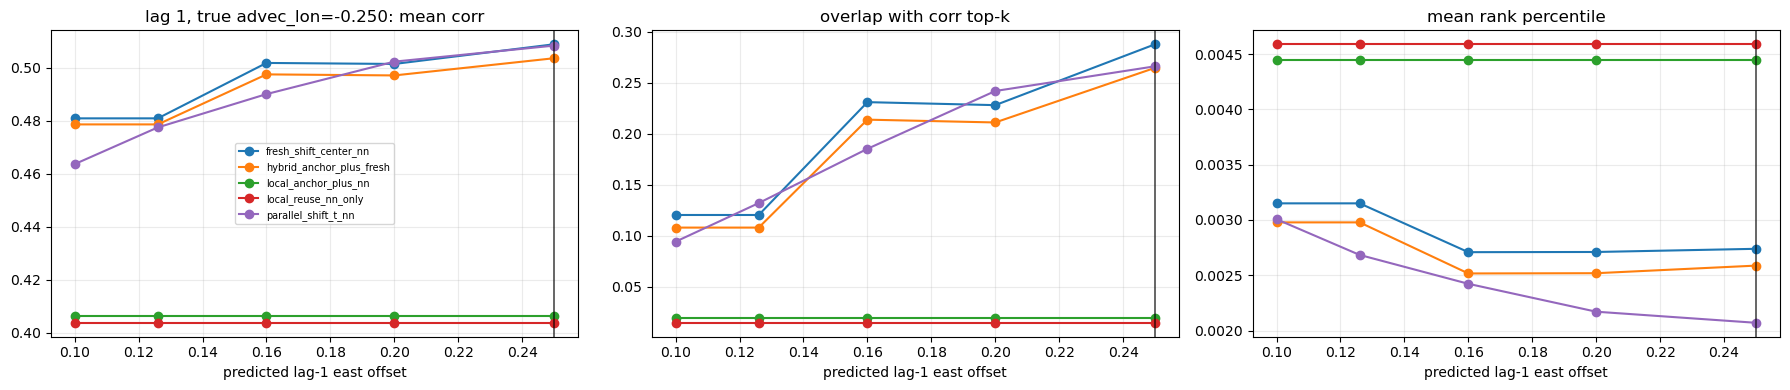

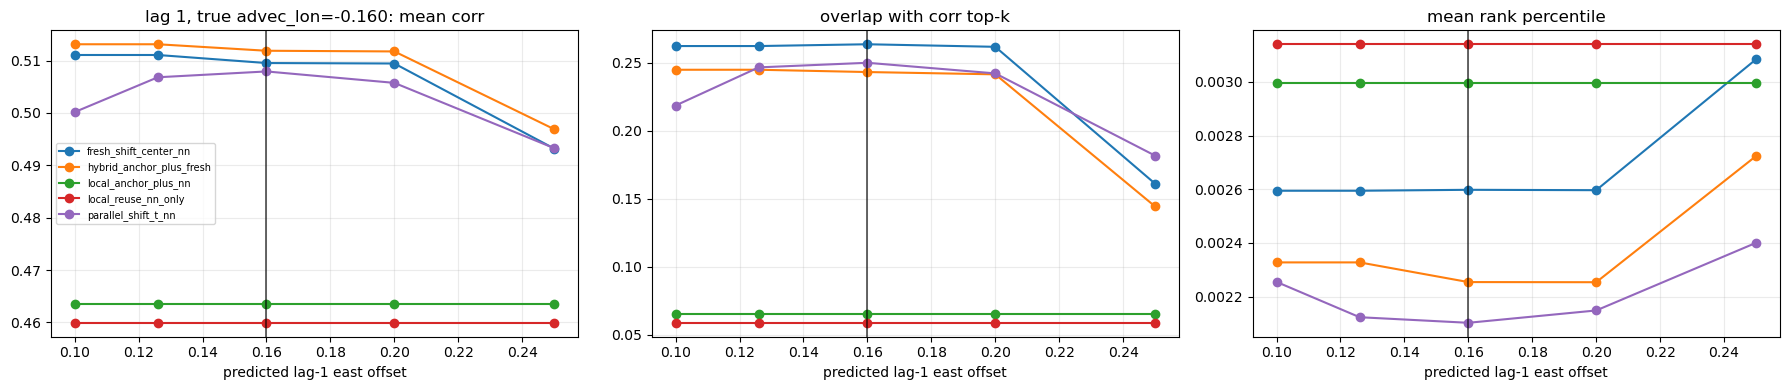

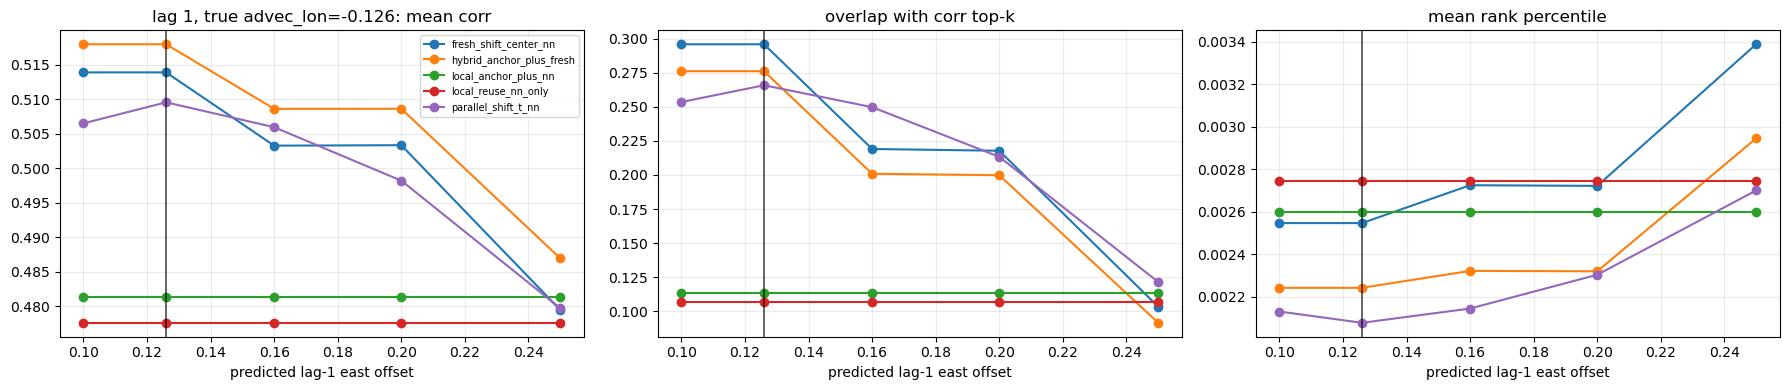

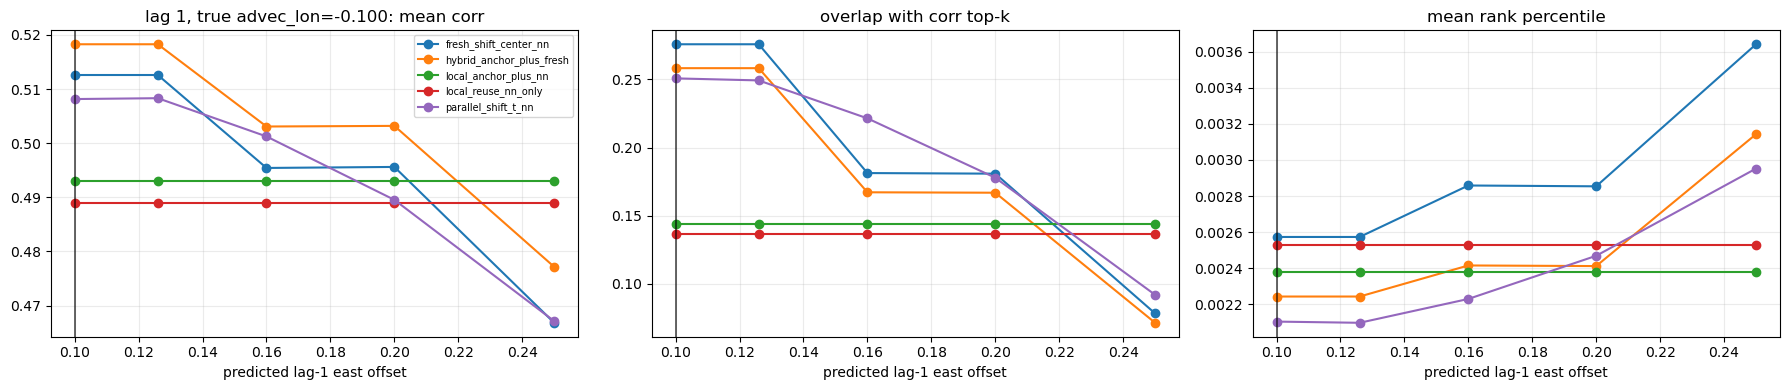

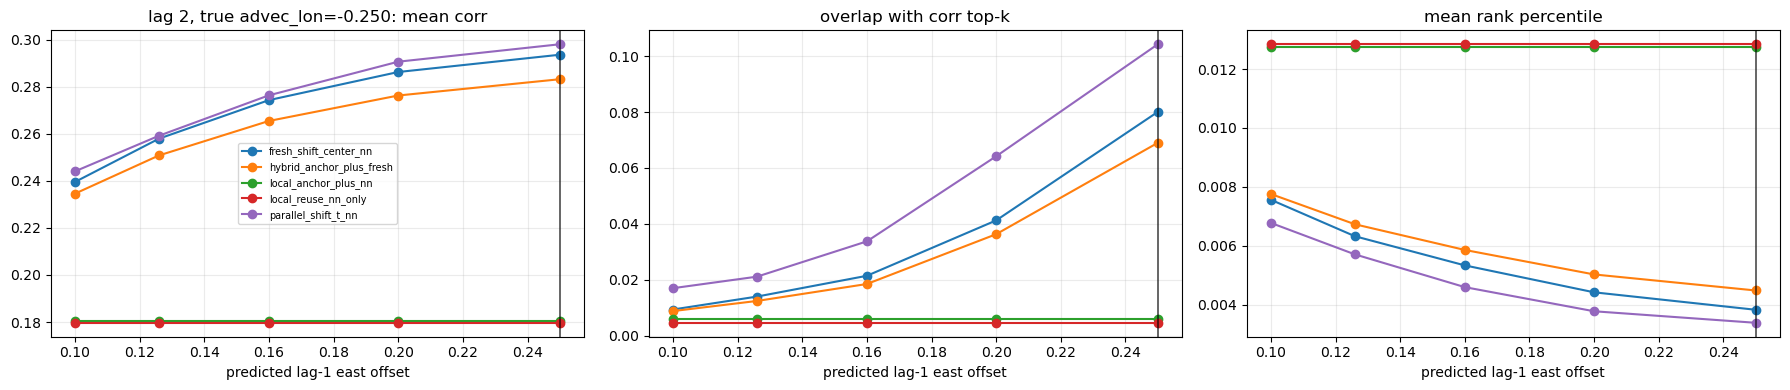

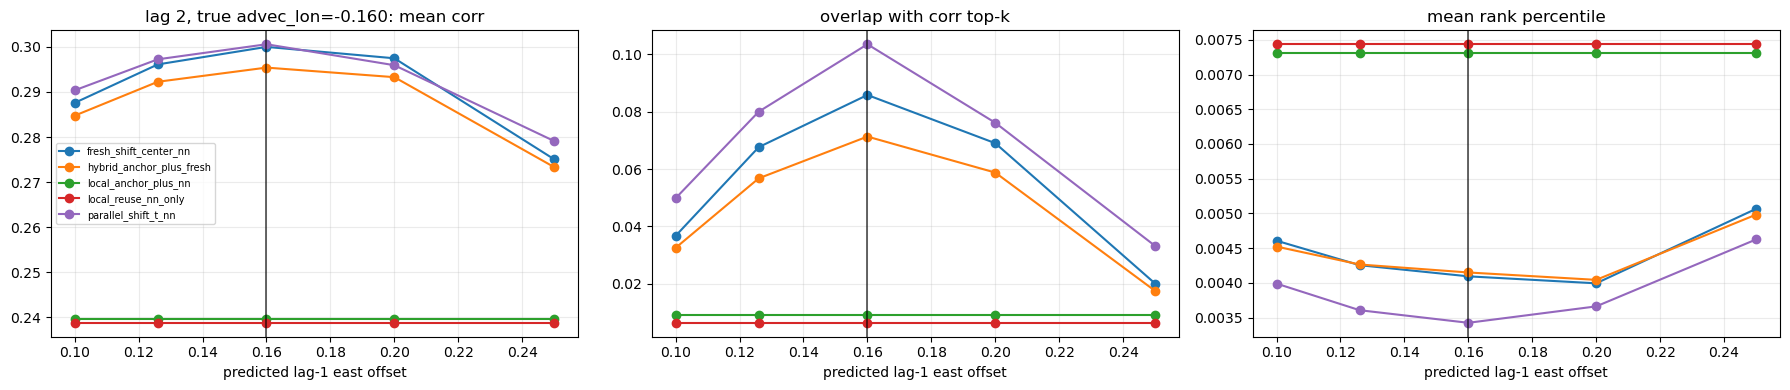

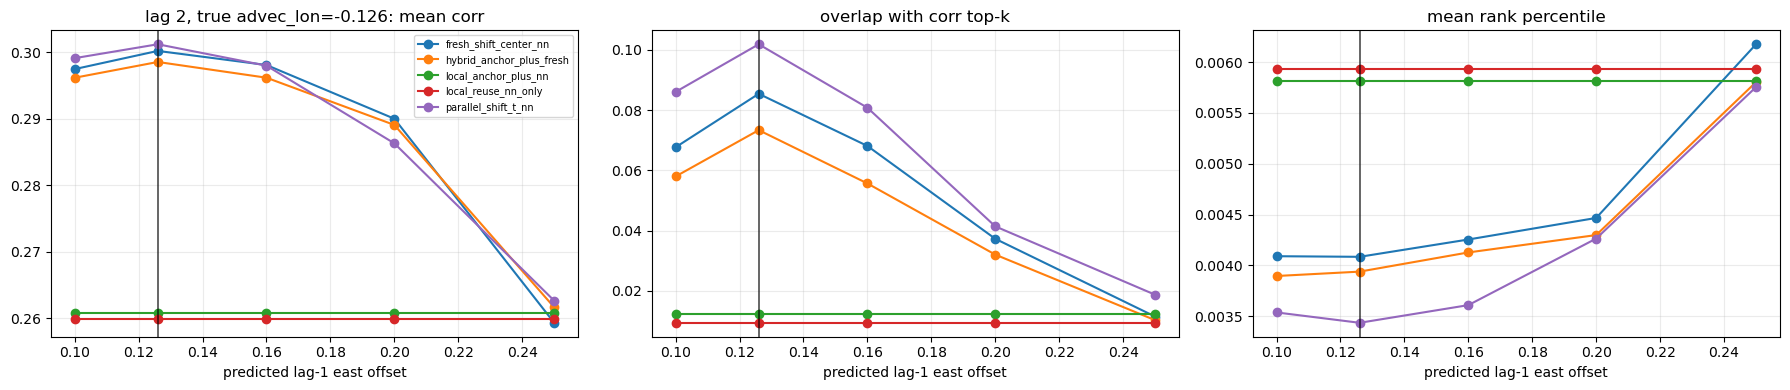

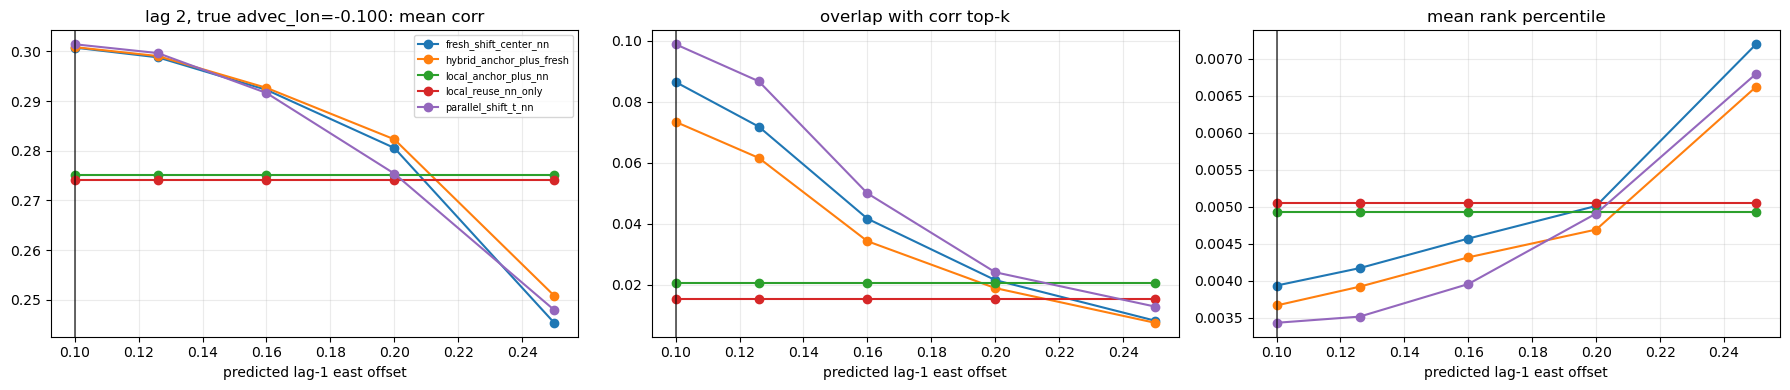

In [12]:
for lag in sorted(lag_summary["lag"].unique()):
    for true_lon, sub in lag_summary[lag_summary["lag"] == lag].groupby("true_advec_lon", sort=True):
        fig, axes = plt.subplots(1, 3, figsize=(18, 4))
        for set_name, ss in sub.groupby("set_name"):
            ss = ss.sort_values("pred_lag1_offset")
            axes[0].plot(ss["pred_lag1_offset"], ss["mean_corr"], marker="o", label=set_name)
            axes[1].plot(ss["pred_lag1_offset"], ss["overlap_topk_mean"], marker="o", label=set_name)
            axes[2].plot(ss["pred_lag1_offset"], ss["mean_rank_pct"], marker="o", label=set_name)
        for ax in axes:
            ax.axvline(abs(true_lon), color="black", linewidth=1.2, alpha=0.7)
            ax.set_xlabel("predicted lag-1 east offset")
            ax.grid(alpha=0.25)
        axes[0].set_title(f"lag {lag}, true advec_lon={true_lon:.3f}: mean corr")
        axes[1].set_title("overlap with corr top-k")
        axes[2].set_title("mean rank percentile")
        axes[0].legend(fontsize=7)
        plt.tight_layout()
        plt.show()


## Single-Target Inspection


In [13]:
INSPECT_LAG = 1
INSPECT_TRUE_ADVEC_LON = -0.126
INSPECT_PRED_OFFSET = 0.126
INSPECT_TARGET_ORDER_IDX = int(eligible[len(eligible) // 2])

lag = INSPECT_LAG
lag_t_idx = TARGET_T_IDX - lag
true_dict = make_true_dict(INSPECT_TRUE_ADVEC_LON)
pred_shift = abs(INSPECT_PRED_OFFSET) * lag
cand_coords = coords_by_t[lag_t_idx]
cand_valid = valid_by_t[lag_t_idx]
valid_indices = np.where(cand_valid)[0]
valid_coords = cand_coords[valid_indices]
center_lookup = build_shift_lookup_base(INSPECT_PRED_OFFSET, multiplier=lag)
i = INSPECT_TARGET_ORDER_IDX
target = t_coords[i]

corr = np.full(len(ordered_base_coords), -np.inf, dtype=np.float64)
corr[valid_indices] = latent_corr_current_to_candidate(target, valid_coords, dt=float(lag), true_dict=true_dict)

top_idx = topk_corr_indices(corr, TOP_K)
t_nn = clean_unique(nns_grid[i], k=TOP_K)
local_anchor = clean_unique([i, *list(nns_grid[i])], valid_mask=cand_valid, k=TOP_K)
q_parallel = ordered_base_coords[t_nn].copy(); q_parallel[:, 1] += pred_shift
parallel = clean_unique(nearest_valid_obs_indices(q_parallel, valid_coords, valid_indices), valid_mask=cand_valid, k=TOP_K)
center_idx = int(center_lookup[i])
fresh = clean_unique([center_idx, *list(nns_grid[center_idx])], valid_mask=cand_valid, k=TOP_K)
hybrid = clean_unique([i, center_idx, *list(nns_grid[center_idx])], valid_mask=cand_valid, k=TOP_K)

def inspect_table(label, idx):
    ranks = ranks_from_corr(corr)
    return pd.DataFrame({
        "set": label,
        "order_idx": idx,
        "lat": cand_coords[idx, 0],
        "lon": cand_coords[idx, 1],
        "corr": corr[idx],
        "rank": ranks[idx],
    })

inspect_df = pd.concat([
    inspect_table("lag_corr_top", top_idx),
    inspect_table("local_anchor_plus_nn", local_anchor),
    inspect_table("parallel_shift_t_nn", parallel),
    inspect_table("fresh_shift_center_nn", fresh),
    inspect_table("hybrid_anchor_plus_fresh", hybrid),
])
print("target order idx:", i, "target coord:", target)
print("candidate lag:", lag, "candidate time idx:", lag_t_idx)
display(inspect_df.sort_values(["set", "rank"]))


target order idx: 9027 target coord: [  1.0342461 123.9382   ]
candidate lag: 1 candidate time idx: 3


,set,order_idx,lat,lon,corr,rank
2,fresh_shift_center_nn,6570,1.023459,124.067820,0.576526,8
4,fresh_shift_center_nn,2332,1.023649,124.006070,0.565655,11
0,fresh_shift_center_nn,9044,1.066864,124.068210,0.535092,19
5,fresh_shift_center_nn,9030,1.067054,124.006460,0.526210,24
3,fresh_shift_center_nn,1651,1.066793,124.131775,0.523342,25
7,fresh_shift_center_nn,9027,1.067338,123.944780,0.499716,30
1,fresh_shift_center_nn,3604,1.110270,124.068596,0.486009,37
6,fresh_shift_center_nn,4740,1.153869,124.007230,0.429804,59
3,hybrid_anchor_plus_fresh,6570,1.023459,124.067820,0.576526,8
5,hybrid_anchor_plus_fresh,2332,1.023649,124.006070,0.565655,11


## Reading Guide

For each lag and true advection value:

- `mean_corr`: average correlation of the selected candidate set with the current target. Higher is better.
- `overlap_topk_mean`: fraction of the true correlation top-k recovered by the candidate set. Higher is better.
- `fresh_gt_local_anchor_rate`: fraction of target locations where shifted-center beats same-location anchor + local NN.
- `hybrid_gt_local_anchor_rate`: whether adding shifted-center geometry on top of the same-location anchor improves local consistency.

Interpretation should be conservative:

- If fresh/hybrid wins mainly for strong advection, local consistency matters for weak advection.
- If hybrid beats both local and fresh, the best conditioning set should mix same-location/local geometry and advective shifted-center geometry.
- If parallel shift is close to fresh, preserving the t-neighbor geometry after shifting is not wrong; if fresh wins clearly, reselecting neighbors around the shifted center matters.